In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

## Hermes-3 

In [2]:
parent_dir = '/Users/lloyd/Documents/hermes_dir/simulations_dir/2025-12_intial_solps_baseline'

cs = {}

for geom in ['geom', 'no_geom']:
    if geom == 'geom':
        broadening = ['trasport_broadening', 'no_transport_broadening']
        for b in broadening:
            for ring in ['0-2_average', '0']:
                cs[f'{geom}_{b}_{ring}'] = Load.case_1D(
                    os.path.join(parent_dir, geom, b, f'sol_ring_{ring}'),
                    use_squash=True
                ).ds.isel(t = -1)
    else:
        cs[f'{geom}_ring_0'] = Load.case_1D(
            os.path.join(parent_dir, geom, f'sol_ring_0'),
            use_squash=True
        ).ds.isel(t = -1)


print(cs.keys())




- Looking for squash file
- Squash file found. squash date 12/10/2025, 13:05:17, dmp file date 12/10/2025, 15:12:44
- dmp files are newer than the squash file! Recreating...
- Done
Replacing guard cells
- Looking for squash file
- Squash file found. squash date 12/10/2025, 13:20:24, dmp file date 12/10/2025, 15:13:10
- dmp files are newer than the squash file! Recreating...
- Done
Replacing guard cells
- Looking for squash file
- Squash file found. squash date 12/10/2025, 13:05:20, dmp file date 12/10/2025, 15:12:10
- dmp files are newer than the squash file! Recreating...
- Done
Replacing guard cells
- Looking for squash file
- Squash file found. squash date 12/10/2025, 13:20:27, dmp file date 12/10/2025, 15:11:06
- dmp files are newer than the squash file! Recreating...
- Done
Replacing guard cells
- Looking for squash file
- Squash file found. squash date 12/10/2025, 13:20:28, dmp file date 12/10/2025, 15:11:17
- dmp files are newer than the squash file! Recreating...
- Done
Replaci

In [3]:
print(cs['geom_trasport_broadening_0-2_average'].data_vars)


Data variables:
    Bxy                                         (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_iz                                      (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_rec                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed_target_recycle                           (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Edd+_cx                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_iz                                      (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fd+_rec                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Fdd+_cx                                     (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    G1                                          (pos) float64 3kB dask.array<chunksize=(

## SOLPS

In [4]:
solps_case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')



# $\lambda_{int}$ simple plot

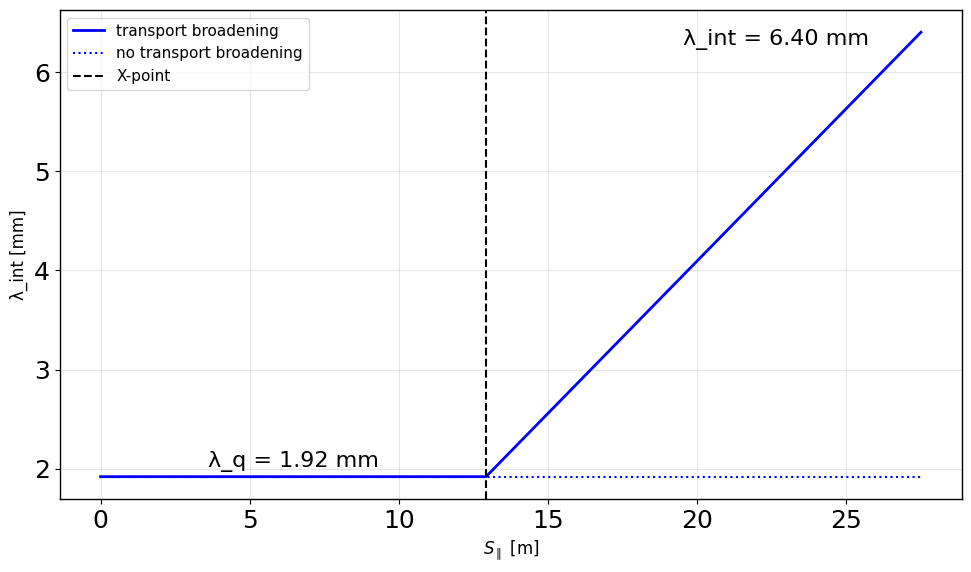

OMP to X-point: λ_int = 1.920 mm (constant)
At X-point: λ_int = 1.920 mm
At target: λ_int = 6.401 mm
Broadening factor: 3.334x from X-point to target


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lambda_int(length_total=27.52, length_xpt=12.93, lambda_q=1.92e-3, b=2.334):
    """
    Plot lambda_int profile along flux tube
    
    Parameters:
    -----------
    length_total : float
        Total parallel length from OMP to target [m]
    length_xpt : float
        Parallel length from OMP to X-point [m]
    lambda_q : float
        Upstream heat flux decay length [m]
    b : float
        Dimensionless divertor broadening factor
    """
    
    # Create array of parallel positions
    lpar = np.linspace(0, length_total, 1000)
    
    # Calculate normalized coordinates (with clamp)
    lpar_X1 = np.clip((length_xpt - lpar) / length_xpt, 0, 1)
    lpar_X2 = np.clip((lpar - length_xpt) / (length_total - length_xpt), 0, 1)
    
    # Calculate lambda_int
    lambda_int = lambda_q * (1 + lpar_X2 * b)
    
    # Convert to mm for plotting
    lambda_int_mm = lambda_int * 1e3
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(lpar, lambda_int_mm, linewidth=2, color='blue', label = 'transport broadening')
    ax.plot(lpar, lambda_q * 1e3 * np.ones_like(lpar), color='blue', linestyle=':', label='no transport broadening')
    
    # Mark X-point
    ax.axvline(length_xpt, color='Black', linestyle='--', linewidth=1.5, 
               label=f'X-point')
    
    # Add annotations
    # ax.axhline(lambda_q * 1e3, color='gray', linestyle=':', alpha=0.5)
    ax.text(length_xpt/2, lambda_q * 1e3 * 1.05, 
            f'λ_q = {lambda_q*1e3:.2f} mm', ha='center')
    
    # ax.axhline(lambda_q * (1 + b) * 1e3, color='gray', linestyle=':', alpha=0.5)
    ax.text(length_xpt + (length_total-length_xpt)/1.5, 
            lambda_q * (1 + b) * 1e3 * 0.98,
            f'λ_int = {lambda_q*(1+b)*1e3:.2f} mm', ha='center')
    
    ax.set_xlabel(r'$S_\parallel$ [m]', fontsize=12)
    ax.set_ylabel('λ_int [mm]', fontsize=12)
    # ax.set_title('Transport broadening profile along flux tube', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"OMP to X-point: λ_int = {lambda_q*1e3:.3f} mm (constant)")
    print(f"At X-point: λ_int = {lambda_q*1e3:.3f} mm")
    print(f"At target: λ_int = {lambda_q*(1+b)*1e3:.3f} mm")
    print(f"Broadening factor: {(1+b):.3f}x from X-point to target")

# Use with your values
plot_lambda_int(length_total=27.52, length_xpt=12.93, lambda_q=1.92e-3, b=2.334)

# Or with original values
# plot_lambda_int(length_total=27.52, length_xpt=12.93, lambda_q=1e-3, b=2.0)

# Flux and density (sol ring 0)

(67,)
Total parallel heat flux density at xpoint(bpol_min): 3.81e+01 MW/m² 

e/i ratio: 5.58 

Total electron parallel heat flux density: 3.23e+01 MW/m² 

Total ion heat parallel flux density: 5.79e+00 MW/m² 

Ne at Bpol min: 1.05e+00 $10^19$ m$^-3$ \n
Connection length: 27.52 m 

X-point location: 12.59 m 



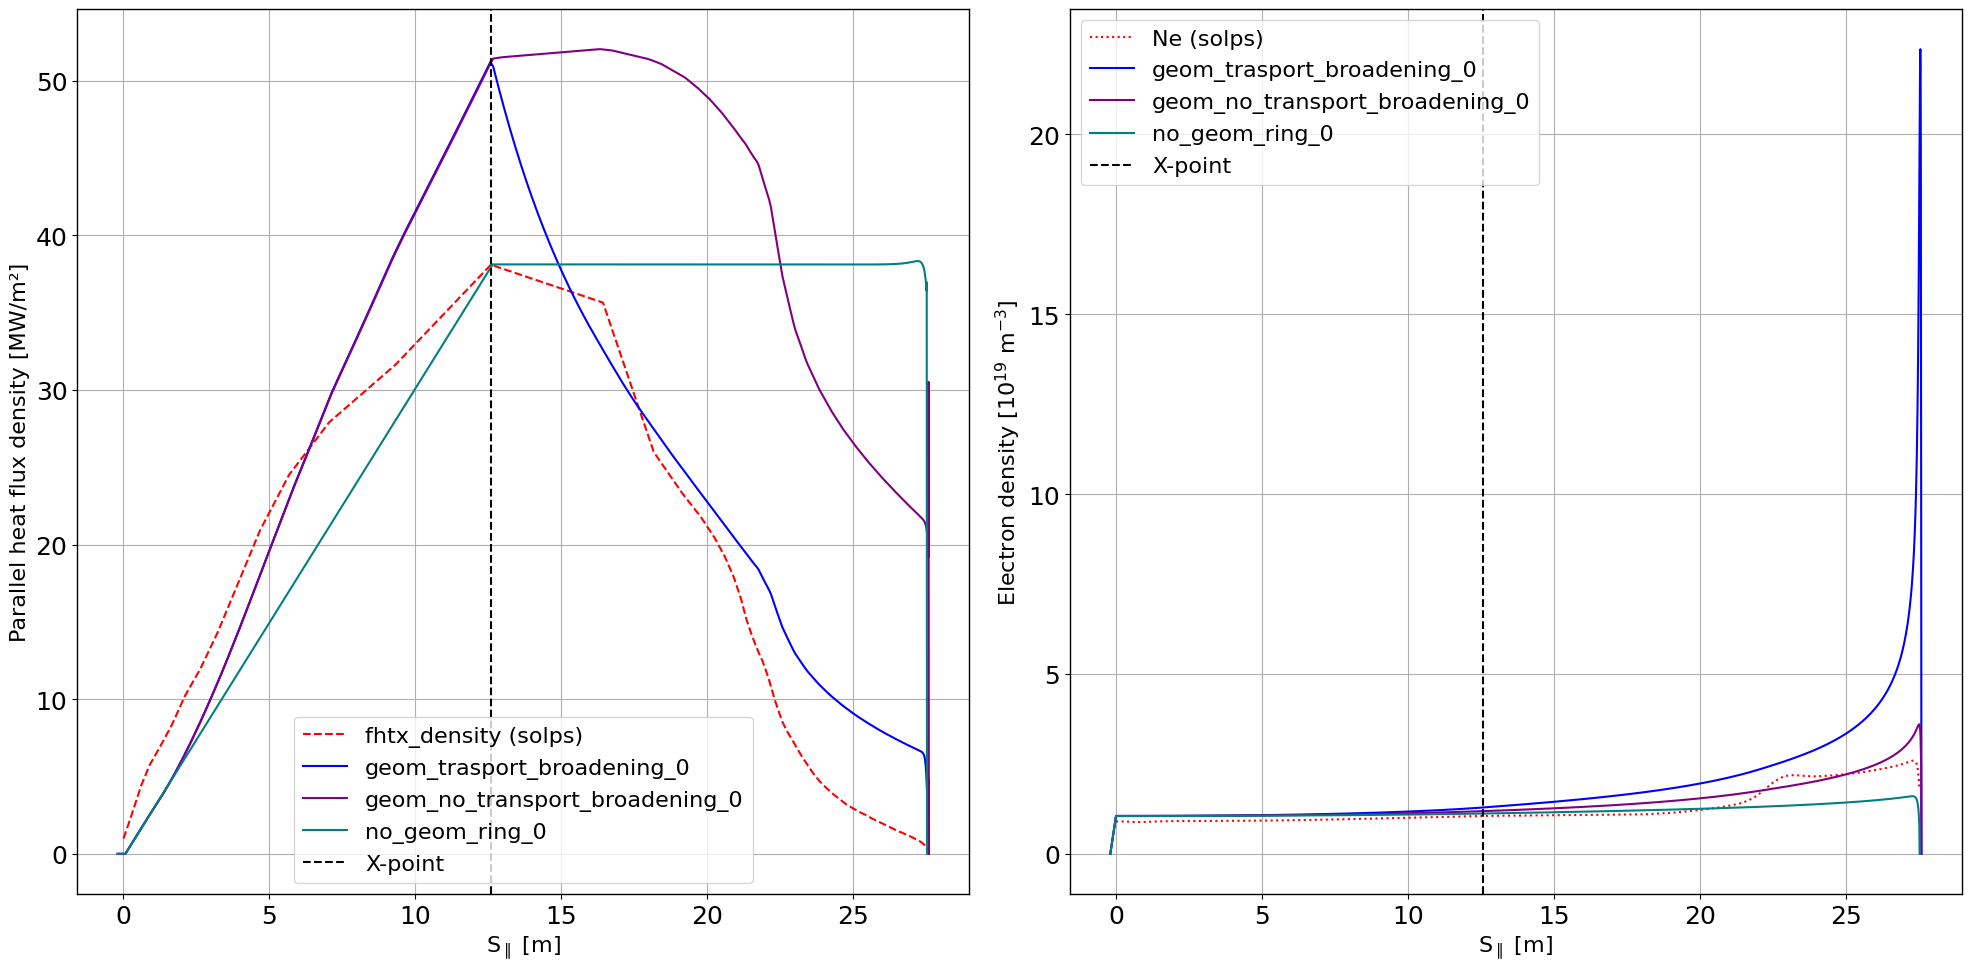

In [6]:
fline = solps_case.get_1d_poloidal_data(
    params=["gs_par", "gs_perp", 'Bpol', 'fhtx_density', 'Ne', 'fhex_total', 'fhix_total'],   
    region='outer_lower',
    sepadd=0,
)

print(np.shape(fline['Spar']))

# Get index of Bpol minimum (usually X-point)
idx_bpol_min = np.argmin(fline["Bpol"])

fhtx_total = fline["fhtx_density"][idx_bpol_min]    # W/m^2
e_over_i = fline["fhex_total"][idx_bpol_min] / fline["fhix_total"][idx_bpol_min]

print('Total parallel heat flux density at xpoint(bpol_min):', f'{fhtx_total * 1e-6:.2e} MW/m² \n')
print('e/i ratio:', f'{e_over_i:.2f} \n' )

# Calculate required electron and ion heat fluxes given total and e/i ratio
# Let f_e = electron heat flux, f_i = ion heat flux
# fhtx_total = f_e + f_i
# e/i ratio = f_e / f_i
# => f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
# => f_i = (1 / (1 + e_over_i)) * fhtx_total

f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
f_i = (1 / (1 + e_over_i)) * fhtx_total

print(f"Total electron parallel heat flux density: {f_e * 1e-6:.2e} MW/m² \n")
print(f"Total ion heat parallel flux density: {f_i * 1e-6:.2e} MW/m² \n")

print('Ne at Bpol min:', fr'{fline["Ne"][(np.argmin(fline["Bpol"]))] * 1e-19:.2e} $10^{19}$ m$^{-3}$ \n')

print('Connection length:', f'{fline["Spar"].values[-1]:.2f} m \n')
print('X-point location:', f'{fline["Spar"][np.argmin(fline["Bpol"])]:.2f} m \n')

# ---- Plot on separate subplots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharex=False)

# First subplot: parallel heat flux density
ax1.plot(fline['Spar'], fline['fhtx_density'] * 1e-6, label='fhtx_density (solps)', color='red', linestyle='--')
# ax1.plot(hermes_case['pos'], (hermes_case['efd+_tot_ylow'] + hermes_case['efe_tot_ylow']) / hermes_case['da'] * 1e-6, label='fhtx_density (hermes)', color='red')
colors = ['blue', 'purple', 'teal']
for idx, i in enumerate([k for k in cs.keys() if '_0' in k and '_0-2_' not in k]):
    color = colors[idx % len(colors)]
    ax1.plot(cs[i]['pos'], ((cs[i]['efd+_tot_ylow'] + cs[i]['efe_tot_ylow']) / cs[i]['da']) * 1e-6, label=i, color=color)
ax1.axvline(fline['Spar'][np.argmin(fline['Bpol'])], color='black', linestyle='--', label='X-point')
ax1.set_ylabel(r"Parallel heat flux density [MW/m²]")
ax1.set_xlabel(r"S$_\parallel$ [m]")
ax1.grid(True)
ax1.legend(loc='best')

# Second subplot: electron density
ax2.plot(fline['Spar'], fline['Ne'] * 1e-19, label='Ne (solps)', color='red', linestyle=':')
# ax2.plot(hermes_case['pos'], hermes_case['Ne'] * 1e-19, label='Ne (hermes)', color='green')
for idx, i in enumerate([k for k in cs.keys() if '_0' in k and '_0-2_' not in k]):
    color = colors[idx % len(colors)]
    ax2.plot(cs[i]['pos'], cs[i]['Ne'] * 1e-19, label=i, color=color)
ax2.axvline(fline['Spar'][np.argmin(fline['Bpol'])], color='black', linestyle='--', label='X-point')
ax2.set_xlabel(r"S$_\parallel$ [m]")
ax2.set_ylabel(r"Electron density [$10^{19}$ m$^{-3}$]")
ax2.grid(True)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

(67,)
Total parallel heat flux density at xpoint(bpol_min): 3.81e+01 MW/m² 

e/i ratio: 5.58 

Total electron parallel heat flux density: 3.23e+01 MW/m² 

Total ion heat parallel flux density: 5.79e+00 MW/m² 

Ne at Bpol min: 1.05e+00 $10^19$ m$^-3$ \n
Connection length: 27.52 m 

X-point location: 12.59 m 



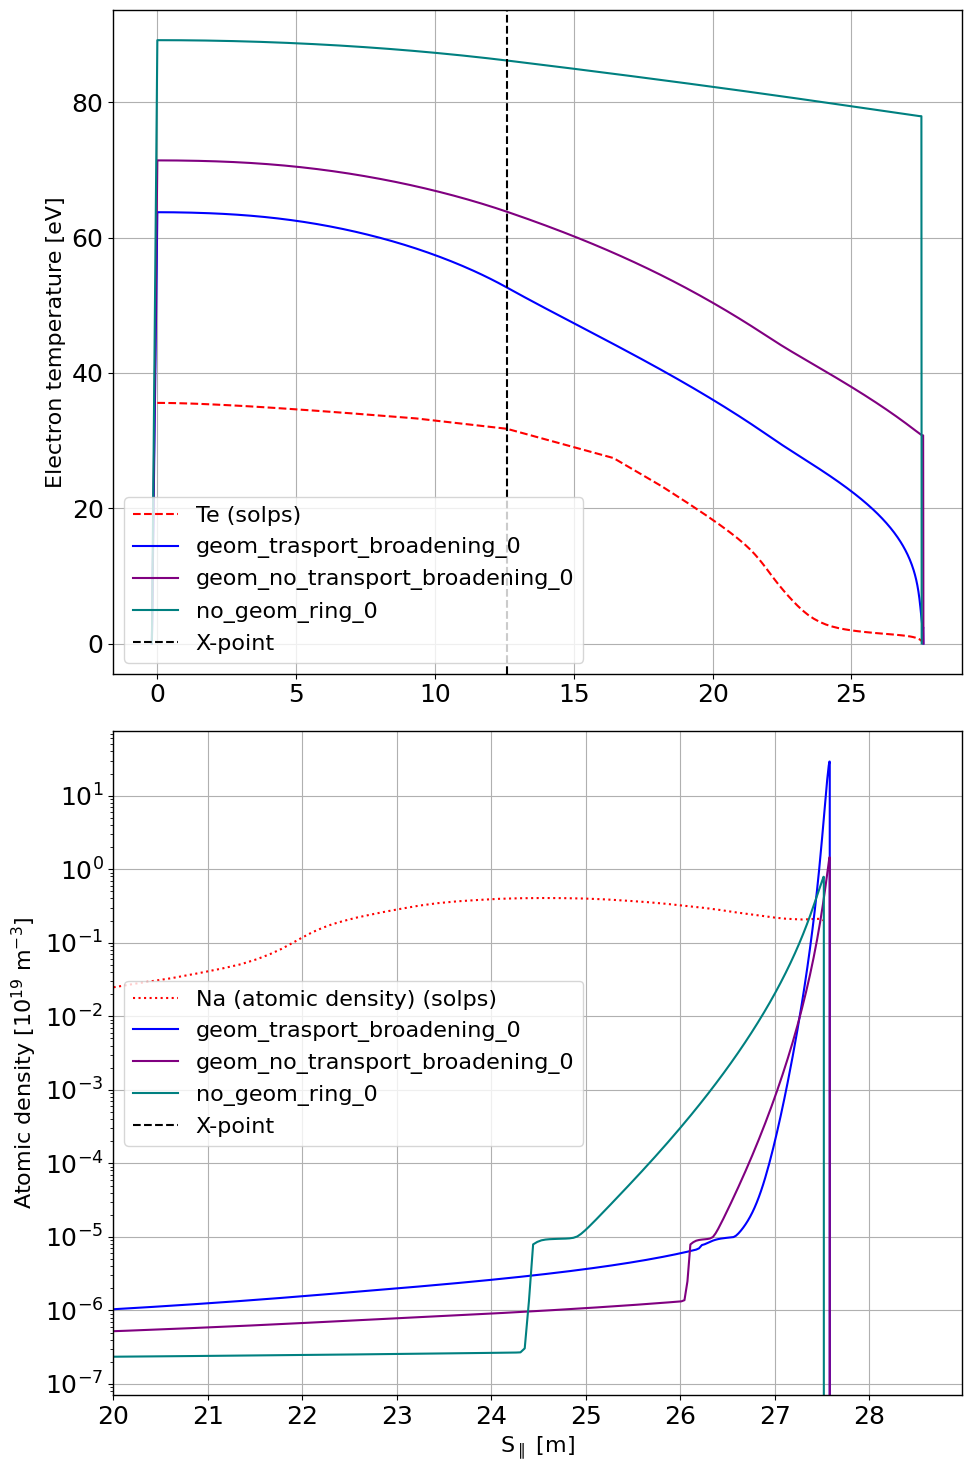

In [7]:
fline = solps_case.get_1d_poloidal_data(
    params=["gs_par", "gs_perp", 'Bpol', 'fhtx_density', 'Ne', 'fhex_total', 'fhix_total', 'Te', 'Na'],   
    region='outer_lower',
    sepadd=0,
)

print(np.shape(fline['Spar']))

# Get index of Bpol minimum (usually X-point)
idx_bpol_min = np.argmin(fline["Bpol"])

fhtx_total = fline["fhtx_density"][idx_bpol_min]    # W/m^2
e_over_i = fline["fhex_total"][idx_bpol_min] / fline["fhix_total"][idx_bpol_min]

print('Total parallel heat flux density at xpoint(bpol_min):', f'{fhtx_total * 1e-6:.2e} MW/m² \n')
print('e/i ratio:', f'{e_over_i:.2f} \n' )

# Calculate required electron and ion heat fluxes given total and e/i ratio
# Let f_e = electron heat flux, f_i = ion heat flux
# fhtx_total = f_e + f_i
# e/i ratio = f_e / f_i
# => f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
# => f_i = (1 / (1 + e_over_i)) * fhtx_total

f_e = (e_over_i / (1 + e_over_i)) * fhtx_total
f_i = (1 / (1 + e_over_i)) * fhtx_total

print(f"Total electron parallel heat flux density: {f_e * 1e-6:.2e} MW/m² \n")
print(f"Total ion heat parallel flux density: {f_i * 1e-6:.2e} MW/m² \n")

print('Ne at Bpol min:', fr'{fline["Ne"][(np.argmin(fline["Bpol"]))] * 1e-19:.2e} $10^{19}$ m$^{-3}$ \n')

print('Connection length:', f'{fline["Spar"].values[-1]:.2f} m \n')
print('X-point location:', f'{fline["Spar"][np.argmin(fline["Bpol"])]:.2f} m \n')

# ---- Plot on separate subplots ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15), sharex=False)

# First subplot: parallel heat flux density
ax1.plot(fline['Spar'], fline['Te'], label='Te (solps)', color='red', linestyle='--')
# ax1.plot(hermes_case['pos'], (hermes_case['efd+_tot_ylow'] + hermes_case['efe_tot_ylow']) / hermes_case['da'] * 1e-6, label='fhtx_density (hermes)', color='red')
colors = ['blue', 'purple', 'teal']
for idx, i in enumerate([k for k in cs.keys() if '_0' in k and '_0-2_' not in k]):
    color = colors[idx % len(colors)]
    ax1.plot(cs[i]['pos'], cs[i]['Te'], label=i, color=color)
ax1.axvline(fline['Spar'][np.argmin(fline['Bpol'])], color='black', linestyle='--', label='X-point')
ax1.set_ylabel(r"Electron temperature [eV]")
# ax1.set_xlabel(r"S$_\parallel$ [m]")
ax1.grid(True)
ax1.legend(loc='best')

# Second subplot: electron density
ax2.plot(fline['Spar'], fline['Na'] * 1e-19, label='Na (atomic density) (solps)', color='red', linestyle=':')
# ax2.plot(hermes_case['pos'], hermes_case['Ne'] * 1e-19, label='Ne (hermes)', color='green')
for idx, i in enumerate([k for k in cs.keys() if '_0' in k and '_0-2_' not in k]):
    color = colors[idx % len(colors)]
    ax2.plot(cs[i]['pos'], cs[i]['Nd'] * 1e-19, label=i, color=color)
ax2.axvline(fline['Spar'][np.argmin(fline['Bpol'])], color='black', linestyle='--', label='X-point')
ax2.set_xlabel(r"S$_\parallel$ [m]")
ax2.set_ylabel(r"Atomic density [$10^{19}$ m$^{-3}$]")
ax2.grid(True)
ax2.set_xlim(20, None)
ax2.set_yscale('log')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

# Geometry

geom_trasport_broadening_0-2_average
geom_trasport_broadening_0
geom_no_transport_broadening_0-2_average
geom_no_transport_broadening_0


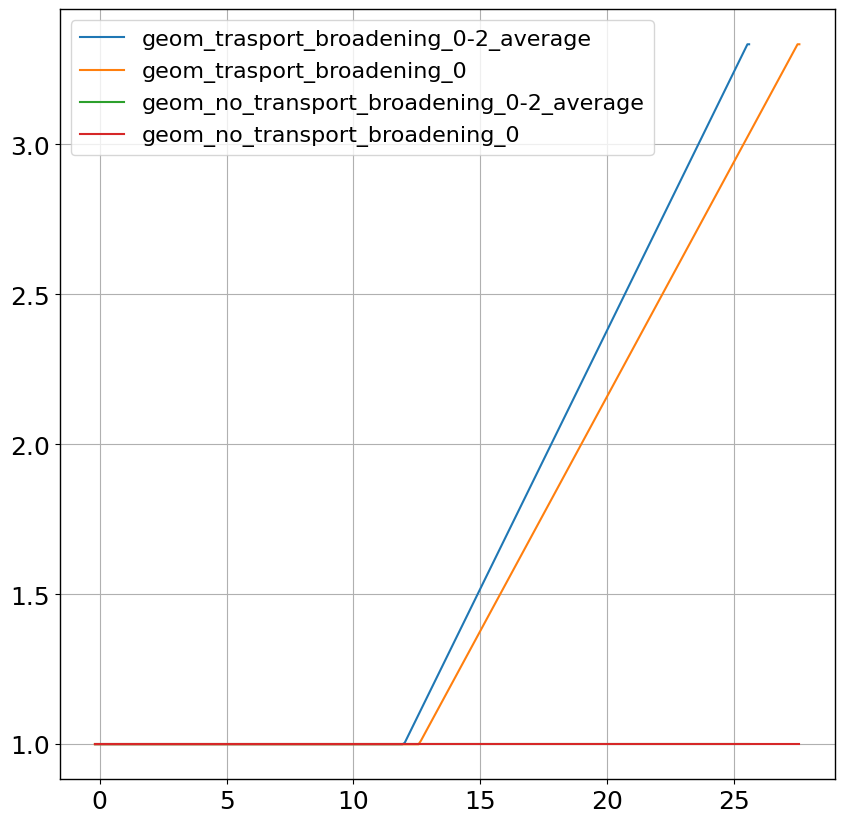

In [15]:
fig,ax = plt.subplots(figsize=(10,10))

for i in cs.keys():
    if 'no_geom' not in i:
        print(i)
        ax.plot(cs[i]['pos'], cs[i]['fieldline_geometry_transport_broadening'], label=i)
ax.legend()
plt.show()


# Reservoir densities